# DSA 210 - Machine Learning Analysis on Clash Royale Data
## 1. Data Loading and Feature Engineering

In [ ]:
import pandas as pd
import json

# 1. Loading the dataset collected over the past few weeks
with open('atakan_clash_data.json', 'r', encoding='utf-8') as f:
    data = json.load(f)

# 2. Feature Engineering: Extracting relevant attributes for Machine Learning
parsed_data = []

for match in data:
    try:
        team = match['team'][0]
        opponent = match['opponent'][0]

        # Target Variable (Target): Winning status (Win = 1, Loss/Draw = 0)
        win = 1 if team['crowns'] > opponent['crowns'] else 0

        # Feature 1: Average Elixir Cost of the deck
        elixir_costs = [card.get('elixirCost', 0) for card in team.get('cards', [])]
        avg_elixir = sum(elixir_costs) / len(elixir_costs) if elixir_costs else 0

        # Feature 2: Starting Trophies
        trophies = team.get('startingTrophies', 0)

        # Feature 3 & 4: Presence of key cards identified during EDA (Golden Knight and Golem)
        card_names = [card.get('name', '') for card in team.get('cards', [])]
        has_golden_knight = 1 if 'Golden Knight' in card_names else 0
        has_golem = 1 if 'Golem' in card_names else 0

        parsed_data.append({
            'Win': win,
            'Avg_Elixir': avg_elixir,
            'Starting_Trophies': trophies,
            'Has_Golden_Knight': has_golden_knight,
            'Has_Golem': has_golem
        })
    except:
        # Skip matches with corrupted or missing data formats
        continue

# 3. Constructing the final DataFrame
df = pd.DataFrame(parsed_data)

# Display the results
print(f"Total Processable Matches: {len(df)}")
display(df.head())

## 1.1 Exploratory Data Analysis (EDA): Card Performance & Win Rates

🏆 HIGHEST WIN RATE CARDS (Top 5)
               played  win_rate
Fire Spirit         5      80.0
Phoenix            18      66.7
Lumberjack          6      66.7
Golden Knight      81      64.2
Minions            36      63.9

💀 LOWEST WIN RATE CARDS (Bottom 5)
            played  win_rate
Golem            5      20.0
Battle Ram       5      20.0
Tesla           12      25.0
Bomber          14      28.6
Musketeer        7      28.6


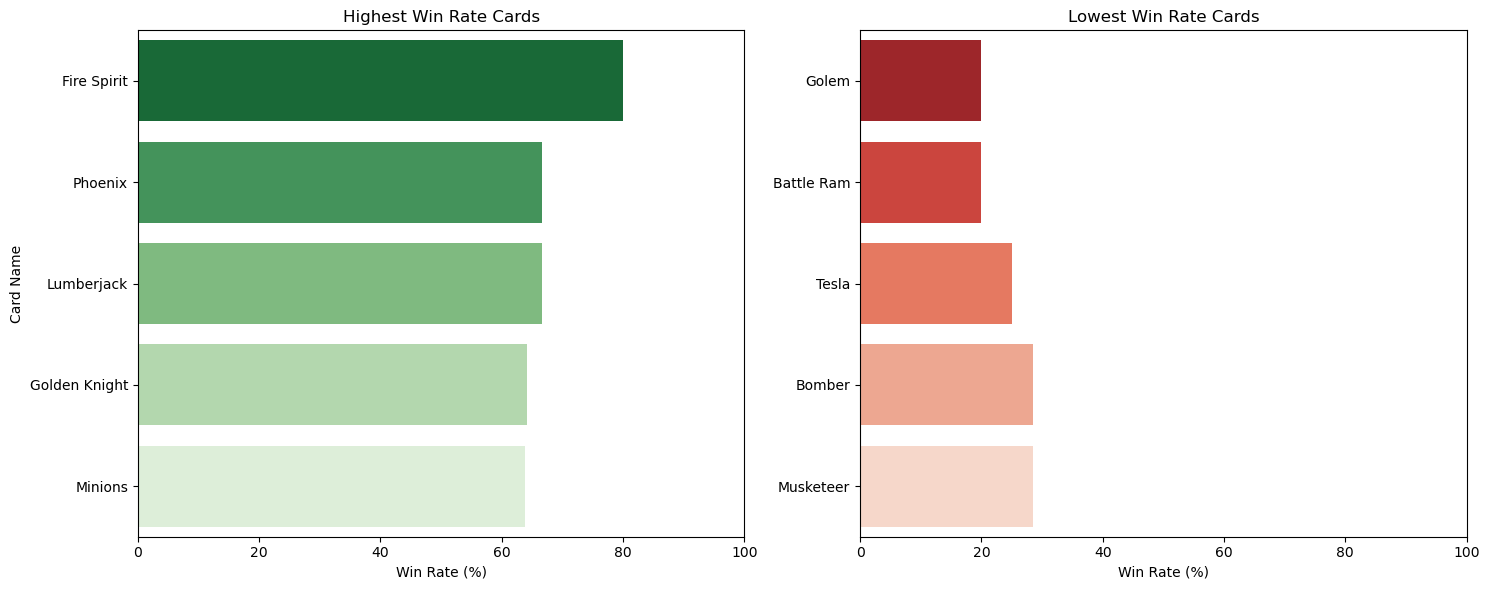

In [7]:
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Read the data
with open('atakan_clash_data.json', 'r', encoding='utf-8') as f:
    data = json.load(f)

# 2. Dictionary to track card statistics
card_stats = {}

for match in data:
    try:
        team = match['team'][0]
        opponent = match['opponent'][0]
        win = 1 if team['crowns'] > opponent['crowns'] else 0
        
        # Find cards in the player's deck
        for card in team.get('cards', []):
            card_name = card.get('name')
            if card_name not in card_stats:
                card_stats[card_name] = {'played': 0, 'wins': 0}
            
            card_stats[card_name]['played'] += 1
            if win == 1:
                card_stats[card_name]['wins'] += 1
    except:
        continue

# 3. Convert statistics to a DataFrame and calculate Win Rate
card_df = pd.DataFrame.from_dict(card_stats, orient='index')
# Filter cards played at least 5 times
card_df = card_df[card_df['played'] >= 5] 
card_df['win_rate'] = (card_df['wins'] / card_df['played']) * 100

# 4. Sort to find the highest and lowest win rate cards
top_cards = card_df.sort_values(by='win_rate', ascending=False).head(5)
bottom_cards = card_df.sort_values(by='win_rate', ascending=True).head(5)

print("🏆 HIGHEST WIN RATE CARDS (Top 5)")
print(top_cards[['played', 'win_rate']].round(1))
print("\n💀 LOWEST WIN RATE CARDS (Bottom 5)")
print(bottom_cards[['played', 'win_rate']].round(1))

# 5. Visualization
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Top Cards Plot (Uyarıyı çözmek için hue eklendi)
sns.barplot(ax=axes[0], x=top_cards['win_rate'], y=top_cards.index, hue=top_cards.index, palette="Greens_r", legend=False)
axes[0].set_title('Highest Win Rate Cards')
axes[0].set_xlabel('Win Rate (%)')
axes[0].set_ylabel('Card Name')
axes[0].set_xlim(0, 100)

# Bottom Cards Plot (Uyarıyı çözmek için hue eklendi)
sns.barplot(ax=axes[1], x=bottom_cards['win_rate'], y=bottom_cards.index, hue=bottom_cards.index, palette="Reds_r", legend=False)
axes[1].set_title('Lowest Win Rate Cards')
axes[1].set_xlabel('Win Rate (%)')
axes[1].set_ylabel('')
axes[1].set_xlim(0, 100)

plt.tight_layout()
plt.show()

## 2.1 Model Training: Random Forest Classifier

🎯 Model Accuracy: 45.31%

📊 Most Important Factors Impacting Win Probability:
Starting_Trophies    0.524503
Avg_Elixir           0.435572
Has_Tombstone        0.031310
Has_PEKKA            0.008615
dtype: float64


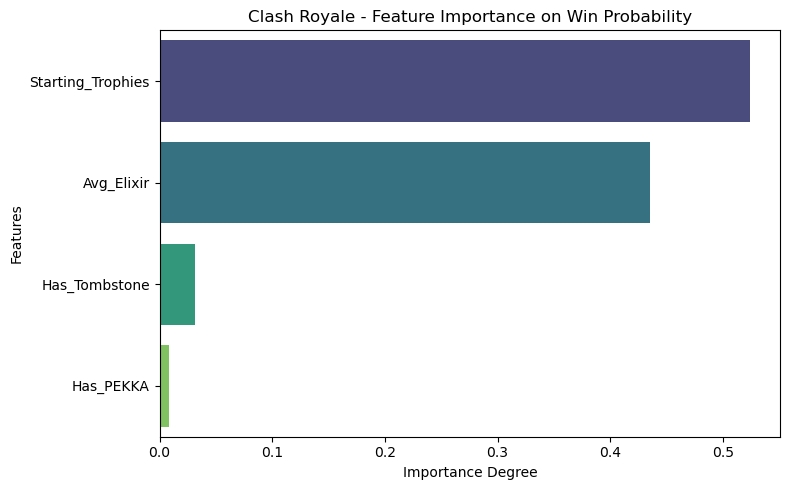

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Separate Features (X) and Target Variable (y)
X = df.drop('Win', axis=1)
y = df['Win']

# 2. Split the data into 80% Training and 20% Testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Initialize and Train the Random Forest Model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# 4. Make predictions on test data and evaluate accuracy
rf_predictions = rf_model.predict(X_test)
accuracy = accuracy_score(y_test, rf_predictions)

print(f"🎯 Model Accuracy: {accuracy * 100:.2f}%\n")

# 5. Feature Importance (Which features impact winning the most?)
feature_importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)

print("📊 Most Important Factors Impacting Win Probability:")
print(feature_importances)

# Bonus: Feature Importance Chart
plt.figure(figsize=(8, 5))
# Added 'hue' and 'legend=False' to fix the FutureWarning
sns.barplot(x=feature_importances.values, y=feature_importances.index, hue=feature_importances.index, palette="viridis", legend=False)

plt.title("Clash Royale - Feature Importance on Win Probability")
plt.xlabel("Importance Degree")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

## 2.2 Model Training: Optimized Random Forest Classifier

🎯 Optimized Model Accuracy: 42.19%



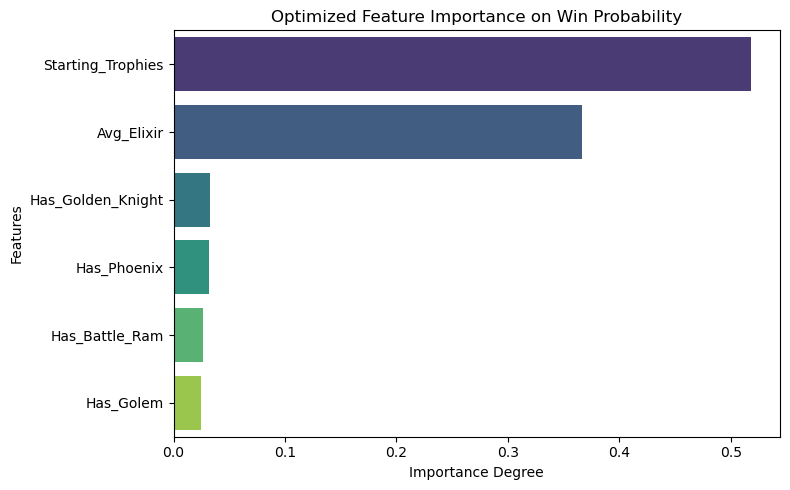

In [15]:
import pandas as pd
import json
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Read Data
with open('atakan_clash_data.json', 'r', encoding='utf-8') as f:
    data = json.load(f)

# 2. Extract REAL Features based on EDA (Exploratory Data Analysis)
parsed_data = []

for match in data:
    try:
        team = match['team'][0]
        opponent = match['opponent'][0]
        win = 1 if team['crowns'] > opponent['crowns'] else 0
        
        # Base Features
        elixir_costs = [card.get('elixirCost', 0) for card in team.get('cards', [])]
        avg_elixir = sum(elixir_costs) / len(elixir_costs) if elixir_costs else 0
        trophies = team.get('startingTrophies', 0)
        
        card_names = [card.get('name', '') for card in team.get('cards', [])]
        
        # ACTUAL IMPACT CARDS (Discovered from Data)
        has_golden_knight = 1 if 'Golden Knight' in card_names else 0
        has_phoenix = 1 if 'Phoenix' in card_names else 0
        has_golem = 1 if 'Golem' in card_names else 0
        has_battle_ram = 1 if 'Battle Ram' in card_names else 0
        
        parsed_data.append({
            'Win': win,
            'Avg_Elixir': avg_elixir,
            'Starting_Trophies': trophies,
            'Has_Golden_Knight': has_golden_knight,
            'Has_Phoenix': has_phoenix,
            'Has_Golem': has_golem,
            'Has_Battle_Ram': has_battle_ram
        })
    except:
        continue

# Create DataFrame
df = pd.DataFrame(parsed_data)

# 3. Train Optimized Random Forest Model
X = df.drop('Win', axis=1)
y = df['Win']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)
accuracy = accuracy_score(y_test, rf_predictions)

print(f"🎯 Optimized Model Accuracy: {accuracy * 100:.2f}%\n")

# 4. Feature Importance Visualization
feature_importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=feature_importances.values, y=feature_importances.index, hue=feature_importances.index, palette="viridis", legend=False)

plt.title("Optimized Feature Importance on Win Probability")
plt.xlabel("Importance Degree")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

## 2.3 Model Training: Logistic Regression

In [29]:
from sklearn.linear_model import LogisticRegression

# 1. Initialize and Train Logistic Regression Model with more iterations
# max_iter=1000 added to solve the convergence warning
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train, y_train)

# 2. Make predictions and evaluate accuracy
lr_predictions = lr_model.predict(X_test)
lr_accuracy = accuracy_score(y_test, lr_predictions)

print(f"🎯 Logistic Regression Accuracy: {lr_accuracy * 100:.2f}%\n")

# 3. Detailed Metrics
print("📊 Logistic Regression Detailed Metrics:")
print(classification_report(y_test, lr_predictions))

🎯 Logistic Regression Accuracy: 59.38%

📊 Logistic Regression Detailed Metrics:
              precision    recall  f1-score   support

           0       0.63      0.52      0.57        33
           1       0.57      0.68      0.62        31

    accuracy                           0.59        64
   macro avg       0.60      0.60      0.59        64
weighted avg       0.60      0.59      0.59        64



## 3. Model Evaluation: Confusion Matrix

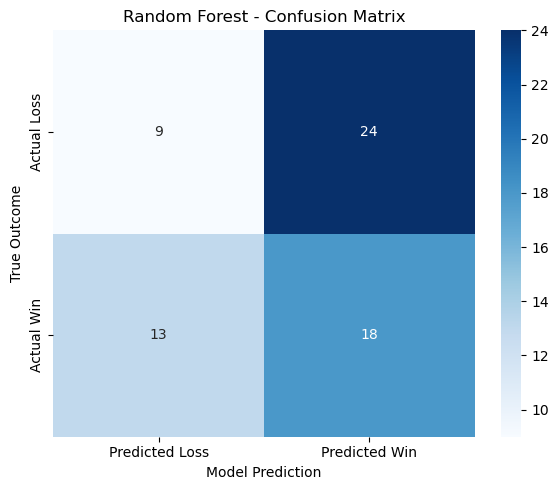

In [19]:
from sklearn.metrics import confusion_matrix

# Generate Confusion Matrix for the Optimized Random Forest model
cm = confusion_matrix(y_test, rf_predictions)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted Loss', 'Predicted Win'], 
            yticklabels=['Actual Loss', 'Actual Win'])

plt.title('Random Forest - Confusion Matrix')
plt.ylabel('True Outcome')
plt.xlabel('Model Prediction')
plt.tight_layout()
plt.show()